# Adaptive ICL

- the test set is the same as in the other notebooks (mulitclassRoBERTA and fewshotCasualLM)
- from the train set will be take 10% of sample as dev set, for choosing the best k-predictor

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from __future__ import print_function
import subprocess
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import time

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise

from src._utils._helpers import get_generated_examples_df

In [2]:
### LOAD DATA ###
# real data
real_train_df = pd.read_csv("real_data/train/agnewstrainAll.csv").rename(columns={"2": "text", "3": "label"})
real_train_df.drop(columns=["0", "1"], inplace=True)

# Take 500 samples for test set
real_train_df, test_df_500 = train_test_split(real_train_df, test_size=500, random_state=42, stratify=real_train_df["label"])
# Store the dev set into a CSV file
# dev_df.to_csv(os.path.join(FOLDER_DIR, "dev_set.csv"), index=False)
# dev_df_500 = pd.read_csv("src/agnews/experiments/RoBERTA_500samples/dev_set.csv")

# synthetic data
syn_targeted_df1, _ = get_generated_examples_df("synthetic_data/datasets/syn_agnews_targeted+tags_500.json")
syn_targeted_df2, _ = get_generated_examples_df("synthetic_data/datasets/syn_agnews_targeted+tags_500_2.json")
syn_targeted_df = pd.concat([syn_targeted_df1, syn_targeted_df2], ignore_index=True)
syn_targeted_df = syn_targeted_df.drop(columns=["phenomena"])

print(f"Real train set     : {real_train_df.shape}")
print(f"Real test set      : {test_df_500.shape}")
print(f"Synthetic train set: {syn_targeted_df.shape}")
print(f"Columns: {real_train_df.columns}")

Real train set     : (2179, 2)
Real test set      : (500, 2)
Synthetic train set: (1000, 2)
Columns: Index(['text', 'label'], dtype='object')


In [3]:
# go to AICL directory

HF_TOKEN = open("./src/_utils/hf_token.txt","r").read() # your huggingface token
HF_CACHE_DIR = "/home/ghi/.cache/huggingface/hub" # where are stored the model

print(os.getcwd())
os.chdir("./src/_utils/_adaptiveICL")
print(os.getcwd())

/home/ghi/Documents/bai-thesis-nlp
/home/ghi/Documents/bai-thesis-nlp/src/_utils/_adaptiveICL


In [4]:
# Huggingface login for LLAMA

command = [
    "huggingface-cli", "login",
    "--token", HF_TOKEN
]

result = subprocess.run(command, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /home/ghi/.cache/huggingface/token
Login successful




In [16]:
def compute_metrics(df):
    # Single-label multi-class classification
    y_true = df["label"].tolist()
    y_pred = df["pred"].tolist()

    return {
        "f1_micro": f1_score(y_true, y_pred, average="micro"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
    }

def execute(cmd):
    popen = subprocess.Popen(cmd, stdout=subprocess.PIPE, universal_newlines=True)
    for stdout_line in iter(popen.stdout.readline, ""):
        yield stdout_line 
    popen.stdout.close()
    return_code = popen.wait()
    if return_code:
        raise subprocess.CalledProcessError(return_code, cmd)

command = [
    "python", "-m", "src.main", "--help"
]

for line in execute(command):
    print(line, end="")

usage: main.py [-h] [--save_preds] [--no_save_preds] [--prepare]
               [--no_prepare] [--oracle_split {train,test}]
               [--mode {random,similar}] --dataset {sst2,trec,rte,cola,agnews}
               --method {dynamic,static} [--static_split {train,dev,test}]
               --model_name
               {microsoft/phi-2,meta-llama/llama-2-7b-hf,meta-llama/llama-2-13b-hf,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B}
               [--single_precision] [--no_single_precision] [--K_max K_MAX]
               [--gpu_id GPU_ID] [--fraction FRACTION] [--cache_dir CACHE_DIR]
               [--labels_available] [--no_labels_available]

Adaptive ICL

optional arguments:
  -h, --help            show this help message and exit
  --save_preds          Save final predictions
  --no_save_preds
  --prepare             Prepare data for training k-predictor model
  --no_prepare
  --oracle_split {train,test}
                        Set to train if preparing data to train k-predictor,
      

# 1. Llama-2-7b-hf - 1000 real

In [6]:
### Save data in _adaptiveICL/data

agnews_path = "data/agnews/"
os.makedirs(agnews_path, exist_ok=True)
# add test common to all configurations
test_df_500.to_csv(os.path.join(agnews_path, "test.csv"), index=False)
# train: 1000 real
curr_train_df = real_train_df.sample(n=1000, random_state=42).reset_index(drop=True)
curr_train_df.to_csv(os.path.join(agnews_path, "train.csv"), index=False)

In [8]:
### Fixed ICL
# command = [
#     "python", "-m", "src.main",
#     "--dataset", "agnews",
#     "--method", "static",
#     "--model_name", "meta-llama/llama-2-7b-hf", #"deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
#     "--static_split", "dev",
#     "--K_max", "2",
#     "--cache_dir", HF_CACHE_DIR,
# ]

# for line in execute(command):
#     print(line, end="")

In [ ]:
# prepare data for training the k-predictor
command = [
    "python", "-m", "src.main",
    "--prepare",
    "--dataset", "agnews",
    "--method", "dynamic",
    "--model_name",  "meta-llama/llama-2-7b-hf", # "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "--oracle_split", "train",
    "--cache_dir", HF_CACHE_DIR,
]

t0 = time.time()
for line in execute(command):
    print(line, end="")
print(f"Time: {time.time() - t0:.2f} seconds")
# TIME: 65m

{'save_preds': False, 'prepare': True, 'oracle_split': 'train', 'mode': 'similar', 'dataset': 'agnews', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:16<00:00,  8.03s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 118, 1: 327, 2: 111, 3: 344}
Dev labels count after splitting  : {0: 14, 1: 27, 2: 19, 3: 40}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 1,
  "text_a": "The same day the Houston Astros announced that pitcher Andy Pettitte would have surgery on his troublesome left elbow next week, Roger Clemens left last night #39;s game against the Philadelphia Phillies with a strained right calf. ",
  "text_b": ""
}



100%|██████████| 900/900 [1:05:13<00:00,  4.35s/it]


Train set size :  630
Val set size   :  135
Test set size  :  135
best_k
0     366
1     187
2     151
3      66
4      44
5      26
10     16
6      16
7      11
9      10
8       7
Name: count, dtype: int64
best_k
0     256
1     131
2     105
3      46
4      31
5      18
6      12
10     12
9       7
7       7
8       5
Name: count, dtype: int64
best_k
0     55
1     28
2     23
3     10
4      6
5      4
6      2
9      2
7      2
10     2
8      1
Name: count, dtype: int64
best_k
0     55
1     28
2     23
3     10
4      7
5      4
10     2
6      2
7      2
8      1
9      1
Name: count, dtype: int64
{0: 366, 1: 187, 2: 151, 3: 66, 4: 44, 5: 26, 6: 16, 7: 11, 8: 7, 9: 10, 10: 16}
Mean k:  1.6355555555555557
Mean Sequence length: 204.12
Min Sequence length : 61
Max Sequence length : 1070
95th percentile  : 470.2
99th percentile  : 739.0
99.9th percentile: 894.7
Classification Report:
              precision    recall  f1-score   support

           0     0.9487    0.9407    0.94

In [ ]:
command = [
    "python", "-m", "src.main",
    "--dataset", "agnews",
    "--method", "dynamic",
    "--model_name", "meta-llama/llama-2-7b-hf", #"deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "--cache_dir", HF_CACHE_DIR,
    "--save_preds"
]

t0 = time.time()
for line in execute(command):
    print(line, end="")
print(f"Time: {time.time() - t0:.2f} seconds")
# TIME: 4m

{'save_preds': True, 'prepare': False, 'oracle_split': 'test', 'mode': 'similar', 'dataset': 'agnews', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:14<00:00,  7.28s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 118, 1: 327, 2: 111, 3: 344}
Dev labels count after splitting  : {0: 14, 1: 27, 2: 19, 3: 40}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 1,
  "text_a": "The same day the Houston Astros announced that pitcher Andy Pettitte would have surgery on his troublesome left elbow next week, Roger Clemens left last night #39;s game against the Philadelphia Phillies with a strained right calf. ",
  "text_b": ""
}

len train: 630
Epoch:  1 | Train Loss: 0.6853 | Val Loss: 0.6689
Epoch:  2 | Train Loss: 0.6578 | Val Loss: 0.6321
Epoch:  3 | Train Loss: 0.6134 | Val Loss: 0.5943
Epoch:  4 | Train Loss: 0.5840 | Val Loss: 0.5735
Epoch:  5 | Train Loss: 0.5690 | Val Loss: 0.5669
Epoch:  6 | Train Loss: 0.5445 | Val Loss: 0.5572
Epoch:  7 | Train Loss: 0.5357 | Val Loss: 0.5469

100%|██████████| 500/500 [02:46<00:00,  3.00it/s]


Predictions count {1: 15, 2: 15, 4: 280, 5: 41, 6: 8, 8: 120, 9: 7, 10: 14}
Mean k:  5.16
Mean Sequence length: 431.36
Min Sequence length : 107
Max Sequence length : 1234
95th percentile  : 732.0
99th percentile  : 880.47
99.9th percentile: 1164.14
Classification Report:
              precision    recall  f1-score   support

           0     0.7286    0.8226    0.7727        62
           1     1.0000    0.6684    0.8013       187
           2     0.4286    0.6462    0.5153        65
           3     0.7874    0.8763    0.8295       186

    accuracy                         0.7620       500
   macro avg     0.7361    0.7534    0.7297       500
weighted avg     0.8130    0.7620    0.7711       500



In [ ]:
preds_file = "./results/pred_label_agnews_llama-2-7b-hf_dynamic.csv"
preds = pd.read_csv(preds_file)
# store it in agnews/experiments/adaptiveICL
new_dir = "../../agnews/experiments/adaptiveICL_1000samples"
os.makedirs(new_dir, exist_ok=True)
preds.to_csv(os.path.join(new_dir, "pred_label_agnews_llama-2-7b-hf_dynamic_1000real.csv"), index=False)

# compute metrics
results = []
metrics = compute_metrics(preds)
metrics['name'] = "llama2_1000real"
results.append(metrics)
print("Results on test:", metrics, sep="\n")

Results on test:
{'f1_micro': 0.762, 'f1_macro': 0.7297158216906028, 'accuracy': 0.762}


# 2. Llama-2-7b-hf - 500 real + 500 targeted aug

In [26]:
# train: 500 real + 500 synthetic
curr_train_df = pd.concat([
                    real_train_df.sample(n=500, random_state=42).reset_index(drop=True), 
                    syn_targeted_df.sample(n=500, random_state=42).reset_index(drop=True)
                ], ignore_index=True)
curr_train_df.to_csv(os.path.join(agnews_path, "train.csv"), index=False)

In [ ]:
# prepare data for training the k-predictor
command = [
    "python", "-m", "src.main",
    "--prepare",
    "--dataset", "agnews",
    "--method", "dynamic",
    "--model_name",  "meta-llama/llama-2-7b-hf", # "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "--oracle_split", "train",
    "--cache_dir", HF_CACHE_DIR,
]

t0 = time.time()
for line in execute(command):
    print(line, end="")
print(f"Time: {time.time() - t0:.2f} seconds")
# TIME: 55m

{'save_preds': False, 'prepare': True, 'oracle_split': 'train', 'mode': 'similar', 'dataset': 'agnews', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:17<00:00,  8.94s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 247, 1: 211, 2: 149, 3: 293}
Dev labels count after splitting  : {0: 23, 1: 22, 2: 20, 3: 35}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 0,
  "text_a": "Climate change is a critical issue affecting various industries. This document examines the impact of climate change on industries and the strategies businesses are using to mitigate these effects.",
  "text_b": ""
}



100%|██████████| 900/900 [55:07<00:00,  3.67s/it]  


Train set size :  630
Val set size   :  135
Test set size  :  135
best_k
0     495
1     167
2      94
3      36
4      32
5      20
8      17
6      13
10     12
9       7
7       7
Name: count, dtype: int64
best_k
0     347
1     117
2      66
3      26
4      22
5      14
8      11
6       9
10      8
7       5
9       5
Name: count, dtype: int64
best_k
0     74
1     25
2     14
4      5
3      5
5      3
8      3
6      2
10     2
7      1
9      1
Name: count, dtype: int64
best_k
0     74
1     25
2     14
4      5
3      5
8      3
5      3
6      2
10     2
7      1
9      1
Name: count, dtype: int64
{0: 495, 1: 167, 2: 94, 3: 36, 4: 32, 5: 20, 6: 13, 7: 7, 8: 17, 9: 7, 10: 12}
Mean k:  1.2633333333333334
Mean Sequence length: 154.03
Min Sequence length : 57
Max Sequence length : 978
95th percentile  : 381.05
99th percentile  : 606.09
99.9th percentile: 873.72
Classification Report:
              precision    recall  f1-score   support

           0     0.9208    0.9879    0.95

In [ ]:
command = [
    "python", "-m", "src.main",
    "--dataset", "agnews",
    "--method", "dynamic",
    "--model_name", "meta-llama/llama-2-7b-hf", #"deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "--cache_dir", HF_CACHE_DIR,
    "--save_preds"
]

t0 = time.time()
for line in execute(command):
    print(line, end="")
print(f"Time: {time.time() - t0:.2f} seconds")
# TIME: 4m

{'save_preds': True, 'prepare': False, 'oracle_split': 'test', 'mode': 'similar', 'dataset': 'agnews', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:17<00:00,  8.79s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 247, 1: 211, 2: 149, 3: 293}
Dev labels count after splitting  : {0: 23, 1: 22, 2: 20, 3: 35}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 0,
  "text_a": "Climate change is a critical issue affecting various industries. This document examines the impact of climate change on industries and the strategies businesses are using to mitigate these effects.",
  "text_b": ""
}

len train: 630
Epoch:  1 | Train Loss: 0.6831 | Val Loss: 0.6640
Epoch:  2 | Train Loss: 0.6492 | Val Loss: 0.6244
Epoch:  3 | Train Loss: 0.6047 | Val Loss: 0.5932
Epoch:  4 | Train Loss: 0.5735 | Val Loss: 0.5864
Epoch:  5 | Train Loss: 0.5594 | Val Loss: 0.5872
Epoch:  6 | Train Loss: 0.5573 | Val Loss: 0.5751
Epoch:  7 | Train Loss: 0.5413 | Val Loss: 0.5576
Epoch:  8 | Train Loss: 0.5230 | V

100%|██████████| 500/500 [02:47<00:00,  2.98it/s]


Predictions count {0: 5, 1: 4, 4: 2, 5: 240, 6: 159, 7: 2, 8: 79, 10: 9}
Mean k:  5.8
Mean Sequence length: 431.0
Min Sequence length : 86
Max Sequence length : 1017
95th percentile  : 596.1
99th percentile  : 712.74
99.9th percentile: 1001.53
Classification Report:
              precision    recall  f1-score   support

           0     0.5192    0.8710    0.6506        62
           1     1.0000    0.6096    0.7575       187
           2     0.4107    0.7077    0.5198        65
           3     0.8412    0.7688    0.8034       186

    accuracy                         0.7140       500
   macro avg     0.6928    0.7393    0.6828       500
weighted avg     0.8047    0.7140    0.7304       500



In [ ]:
preds_file = "./results/pred_label_agnews_llama-2-7b-hf_dynamic.csv"
preds = pd.read_csv(preds_file)
# store it in agnews/experiments/adaptiveICL
# new_dir = "../../agnews/experiments/adaptiveICL_1000samples"
# os.makedirs(new_dir, exist_ok=True)
preds.to_csv(os.path.join(new_dir, "pred_label_agnews_llama-2-7b-hf_dynamic_500real+500targetedaug.csv"), index=False)

# compute metrics
metrics = compute_metrics(preds)
metrics['name'] = "llama2_500real+500syn"
results.append(metrics)
print("Results on test:", metrics, sep="\n")

Results on test:
{'f1_micro': 0.714, 'f1_macro': 0.6828055726278304, 'accuracy': 0.714, 'name': 'llama2_500real+500syn'}


# 3. Llama-2-7b-hf - 1000 targeted aug


In [32]:
# train: 1000 synthetic
curr_train_df = syn_targeted_df.sample(n=1000, random_state=42).reset_index(drop=True)
curr_train_df.to_csv(os.path.join(agnews_path, "train.csv"), index=False)

In [ ]:
# prepare data for training the k-predictor
command = [
    "python", "-m", "src.main",
    "--prepare",
    "--dataset", "agnews",
    "--method", "dynamic",
    "--model_name",  "meta-llama/llama-2-7b-hf", # "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "--oracle_split", "train",
    "--cache_dir", HF_CACHE_DIR,
]

t0 = time.time()
for line in execute(command):
    print(line, end="")
print(f"Time: {time.time() - t0:.2f} seconds")
# TIME: 50m

{'save_preds': False, 'prepare': True, 'oracle_split': 'train', 'mode': 'similar', 'dataset': 'agnews', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:24<00:00, 12.27s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 324, 1: 136, 2: 194, 3: 246}
Dev labels count after splitting  : {0: 41, 1: 11, 2: 27, 3: 21}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 0,
  "text_a": "Trade statistics show economic growth, impacting markets and the global economy.",
  "text_b": ""
}



100%|██████████| 900/900 [49:10<00:00,  3.28s/it]


Train set size :  630
Val set size   :  135
Test set size  :  135
best_k
0     605
1      96
2      70
3      29
7      19
4      17
5      16
9      15
10     14
8      13
6       6
Name: count, dtype: int64
best_k
0     423
1      68
2      49
3      21
7      13
4      11
5      11
9      11
10     10
8       9
6       4
Name: count, dtype: int64
best_k
0     91
1     14
2     10
3      4
4      3
5      3
7      3
8      2
10     2
9      2
6      1
Name: count, dtype: int64
best_k
0     91
1     14
2     11
3      4
4      3
7      3
10     2
9      2
5      2
8      2
6      1
Name: count, dtype: int64
{0: 605, 1: 96, 2: 70, 3: 29, 4: 17, 5: 16, 6: 6, 7: 19, 8: 13, 9: 15, 10: 14}
Mean k:  1.1322222222222222
Mean Sequence length: 123.23
Min Sequence length : 57
Max Sequence length : 546
95th percentile  : 370.2
99th percentile  : 478.0
99.9th percentile: 520.83
Classification Report:
              precision    recall  f1-score   support

           0     0.8824    0.9722    0.9251

In [ ]:
command = [
    "python", "-m", "src.main",
    "--dataset", "agnews",
    "--method", "dynamic",
    "--model_name", "meta-llama/llama-2-7b-hf", #"deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "--cache_dir", HF_CACHE_DIR,
    "--save_preds"
]

t0 = time.time()
for line in execute(command):
    print(line, end="")
print(f"Time: {time.time() - t0:.2f} seconds")
# TIME: 4m

{'save_preds': True, 'prepare': False, 'oracle_split': 'test', 'mode': 'similar', 'dataset': 'agnews', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:23<00:00, 11.88s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 324, 1: 136, 2: 194, 3: 246}
Dev labels count after splitting  : {0: 41, 1: 11, 2: 27, 3: 21}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 0,
  "text_a": "Trade statistics show economic growth, impacting markets and the global economy.",
  "text_b": ""
}

len train: 630
Epoch:  1 | Train Loss: 0.6779 | Val Loss: 0.6607
Epoch:  2 | Train Loss: 0.6344 | Val Loss: 0.6243
Epoch:  3 | Train Loss: 0.5910 | Val Loss: 0.6009
Epoch:  4 | Train Loss: 0.5595 | Val Loss: 0.5981
Epoch:  5 | Train Loss: 0.5545 | Val Loss: 0.5899
Epoch:  6 | Train Loss: 0.5369 | Val Loss: 0.5661
Epoch:  7 | Train Loss: 0.5036 | Val Loss: 0.5441
Epoch:  8 | Train Loss: 0.4872 | Val Loss: 0.5306
Epoch:  9 | Train Loss: 0.4860 | Val Loss: 0.5210
Epoch: 10 | Train Loss: 0.4747 | Val Loss: 0.5138
E

100%|██████████| 500/500 [01:49<00:00,  4.55it/s]


Predictions count {0: 220, 1: 3, 3: 9, 4: 35, 5: 134, 6: 13, 7: 7, 9: 56, 10: 23}
Mean k:  3.4
Mean Sequence length: 228.53
Min Sequence length : 68
Max Sequence length : 606
95th percentile  : 499.05
99th percentile  : 556.04
99.9th percentile: 602.51
Classification Report:
              precision    recall  f1-score   support

           0     0.4074    0.8871    0.5584        62
           1     1.0000    0.1283    0.2275       187
           2     0.2577    0.6462    0.3684        65
           3     0.6685    0.6398    0.6538       186

    accuracy                         0.4800       500
   macro avg     0.5834    0.5753    0.4520       500
weighted avg     0.7067    0.4800    0.4454       500



In [ ]:
preds_file = "./results/pred_label_agnews_llama-2-7b-hf_dynamic.csv"
preds = pd.read_csv(preds_file)
# store it in agnews/experiments/adaptiveICL
# new_dir = "../../agnews/experiments/adaptiveICL_1000samples"
# os.makedirs(new_dir, exist_ok=True)
preds.to_csv(os.path.join(new_dir, "pred_label_agnews_llama-2-7b-hf_dynamic_1000targetedaug.csv"), index=False)

# compute metrics
metrics = compute_metrics(preds)
metrics['name'] = "llama2_1000syn"
results.append(metrics)
print("Results on test:", metrics, sep="\n")

Results on test:
{'f1_micro': 0.48, 'f1_macro': 0.45203274816356676, 'accuracy': 0.48, 'name': 'llama2_1000syn'}


---

# Results

In [40]:
df_results = pd.DataFrame(results).reset_index(drop=True)
new_order = ["name"] + [col for col in df_results.columns if col != "name"]
df_results = df_results[new_order]
df_results.to_csv(os.path.join(new_dir, "adaptiveICL_results_test.csv"), index=False)
display(df_results.round(3))

,name,f1_micro,f1_macro,accuracy
0,llama2_1000real,0.762,0.730,0.762
1,llama2_500real+500syn,0.714,0.683,0.714
2,llama2_1000syn,0.480,0.452,0.480


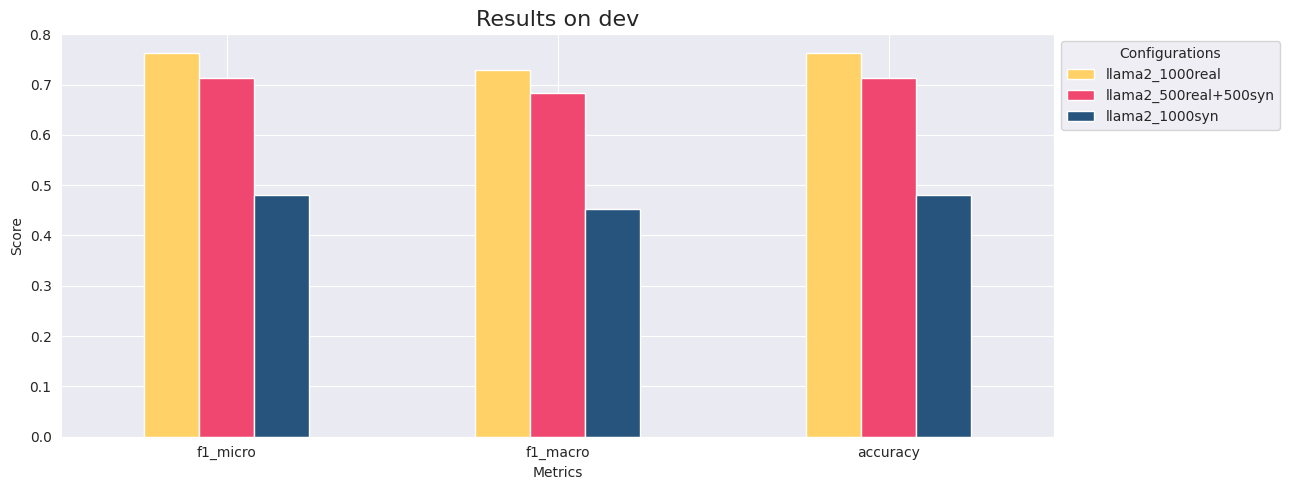

In [45]:
# df_results = pd.read_csv(os.path.join(FOLDER_DIR, "fewshotCasualLM_results_dev.csv"))

plot_df = df_results.set_index('name')
# plot_df["eval_time_norm"] = plot_df["eval_time"] / max(plot_df["eval_time"])
# plot_df.drop(columns=["eval_time"], inplace=True)
# colors = ['#ef476f', '#f78c6b', '#ffd166', '#06d6a0', '#118ab2', '#073b4c', '#aaaaaa']
colors = ['#ffd166', '#ef476f', '#26547c']
ax = plot_df.T.plot(kind='bar', figsize=(13, 5), color=colors)

plt.title('Results on dev', fontsize=16)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Configurations', bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()